### Perbandingan Hasil Model

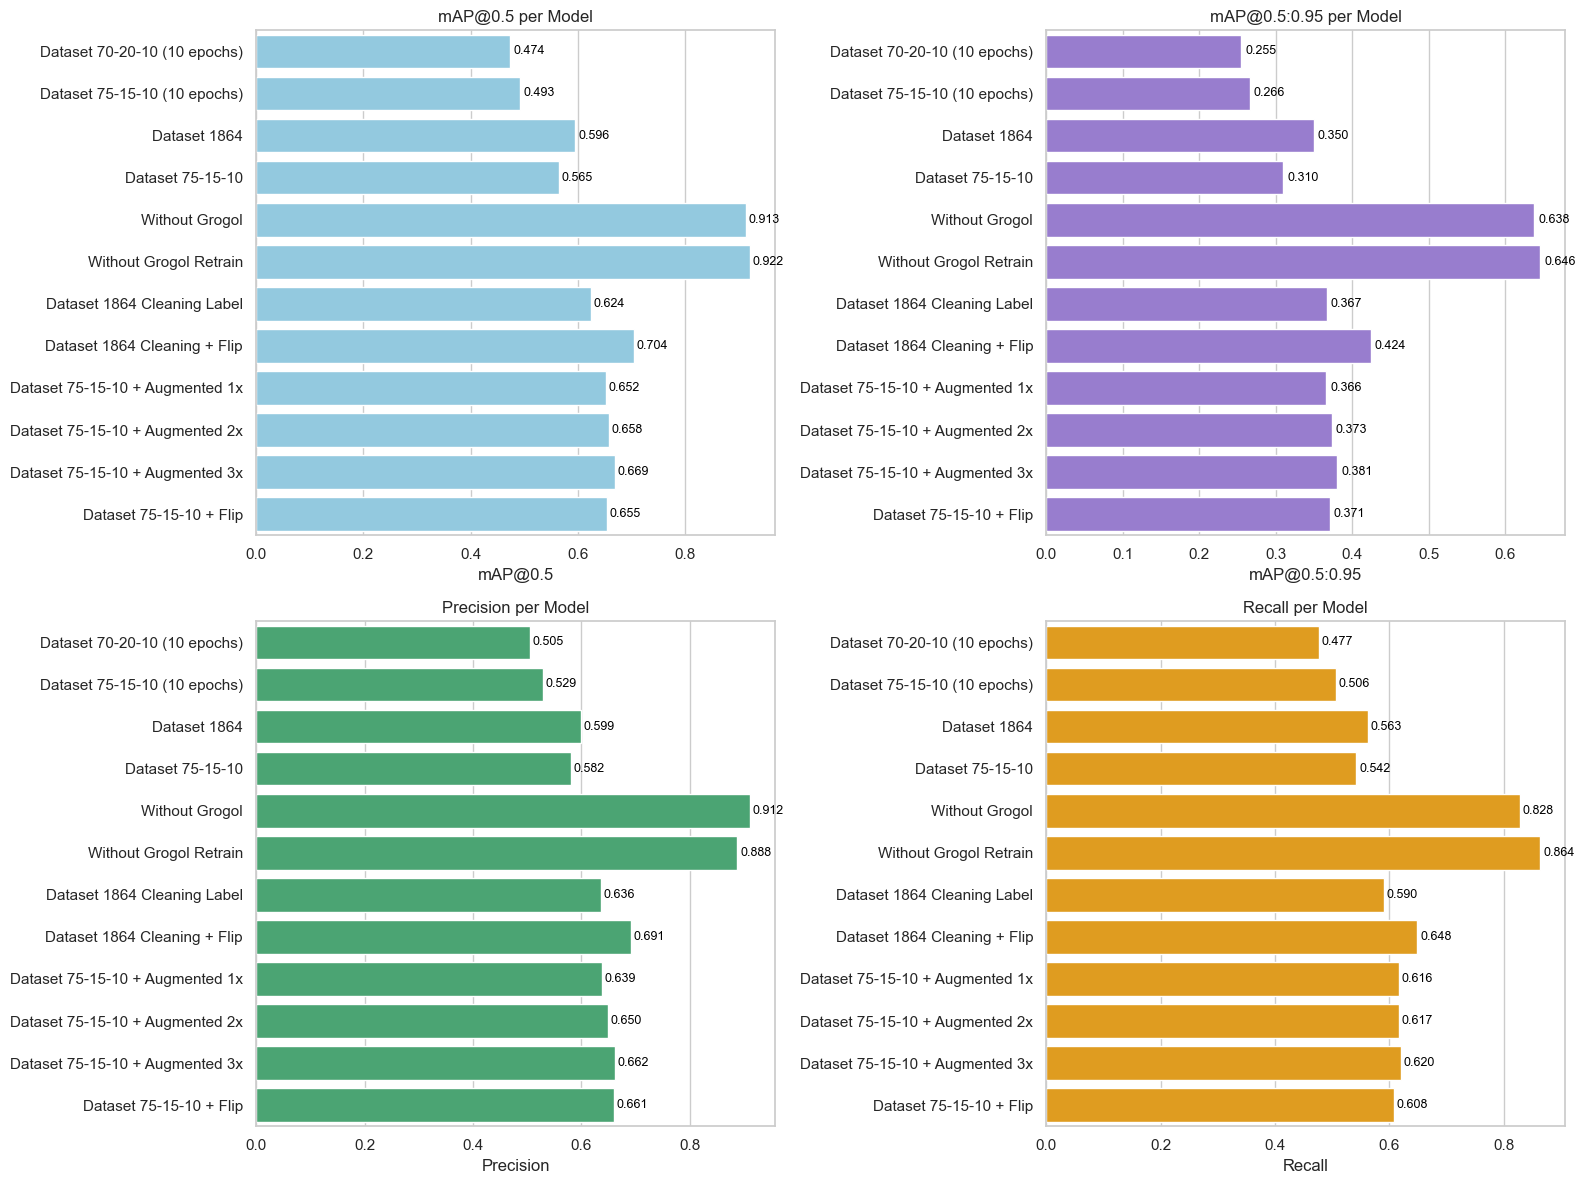

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Daftar path ke file results.csv
csv_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/results.csv",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/results.csv",
    "runs/d_train/y11n_batch16_epochs100_val/results.csv",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/results.csv",
    "runs/withoutgrogol_train/y11n_batch16_epochs100/results.csv",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/results.csv",
    "runs/dataset_clean_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_clean_flip_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/results.csv",
]

# Label model untuk ditampilkan di grafik
labels = [
    "Dataset 70-20-10 (10 epochs)",
    "Dataset 75-15-10 (10 epochs)",
    "Dataset 1864",
    "Dataset 75-15-10",
    "Without Grogol",
    "Without Grogol Retrain",
    "Dataset 1864 Cleaning Label",
    "Dataset 1864 Cleaning + Flip",
    "Dataset 75-15-10 + Augmented 1x",
    "Dataset 75-15-10 + Augmented 2x",
    "Dataset 75-15-10 + Augmented 3x",
    "Dataset 75-15-10 + Flip",
]

# List untuk menyimpan semua data
all_data = []

# Baca semua CSV
for path, label in zip(csv_paths, labels):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Bersihkan spasi

        try:
            # Ambil epoch dengan nilai mAP50 tertinggi
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            all_data.append({
                "Label": label,
                "Precision": best["metrics/precision(B)"],
                "Recall": best["metrics/recall(B)"],
                "mAP50": best["metrics/mAP50(B)"],
                "mAP50-95": best["metrics/mAP50-95(B)"]
            })
        except KeyError as e:
            print(f"Kolom tidak ditemukan di {path}: {e}")
    else:
        print(f"Tidak ditemukan: {path}")

# Gabungkan ke DataFrame
results_df = pd.DataFrame(all_data)

# Fungsi untuk menambahkan angka di atas batang
def add_bar_labels(ax, fmt="%.3f"):
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                    fmt % width,
                    ha='left', va='center', fontsize=9, color='black')

# Visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# mAP@0.5
plt.subplot(2, 2, 1)
ax1 = sns.barplot(x="mAP50", y="Label", data=results_df, color="skyblue")
plt.title("mAP@0.5 per Model")
plt.xlabel("mAP@0.5")
plt.ylabel("")
add_bar_labels(ax1)

# mAP@0.5:0.95
plt.subplot(2, 2, 2)
ax2 = sns.barplot(x="mAP50-95", y="Label", data=results_df, color="mediumpurple")
plt.title("mAP@0.5:0.95 per Model")
plt.xlabel("mAP@0.5:0.95")
plt.ylabel("")
add_bar_labels(ax2)

# Precision
plt.subplot(2, 2, 3)
ax3 = sns.barplot(x="Precision", y="Label", data=results_df, color="mediumseagreen")
plt.title("Precision per Model")
plt.xlabel("Precision")
plt.ylabel("")
add_bar_labels(ax3)

# Recall
plt.subplot(2, 2, 4)
ax4 = sns.barplot(x="Recall", y="Label", data=results_df, color="orange")
plt.title("Recall per Model")
plt.xlabel("Recall")
plt.ylabel("")
add_bar_labels(ax4)

plt.tight_layout()
plt.show()

### Perbandingan Hasil PR_curve.png

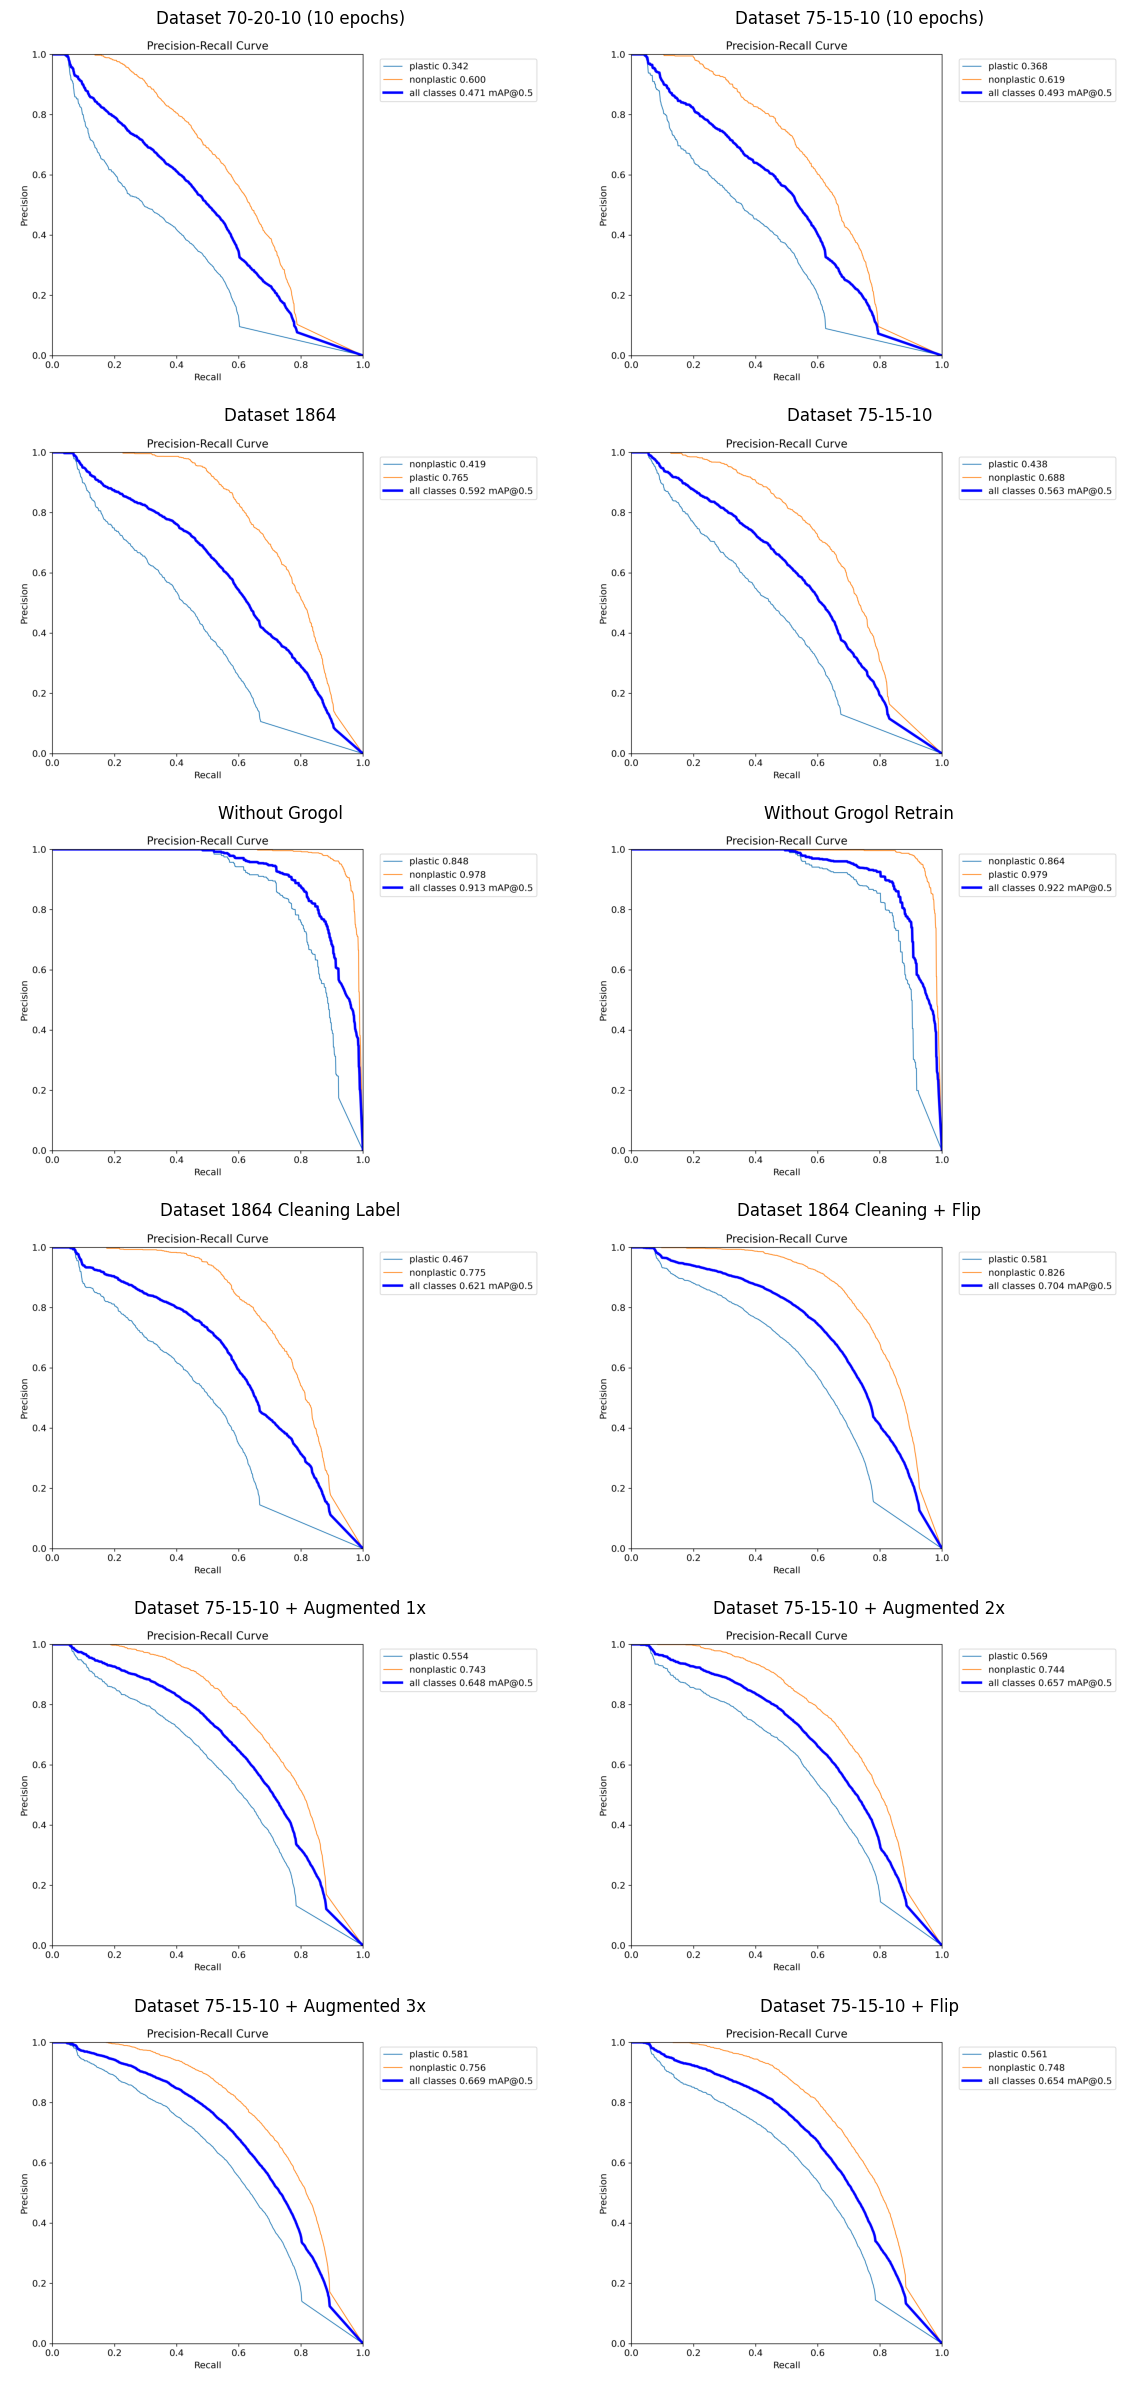

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# List path gambar PR_curve.png
image_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/PR_curve.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/PR_curve.png",
    "runs/d_train/y11n_batch16_epochs100_val/PR_curve.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/withoutgrogol_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_clean_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_clean_flip_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/PR_curve.png",
]

labels = [
    "Dataset 70-20-10 (10 epochs)",
    "Dataset 75-15-10 (10 epochs)",
    "Dataset 1864",
    "Dataset 75-15-10",
    "Without Grogol",
    "Without Grogol Retrain",
    "Dataset 1864 Cleaning Label",
    "Dataset 1864 Cleaning + Flip",
    "Dataset 75-15-10 + Augmented 1x",
    "Dataset 75-15-10 + Augmented 2x",
    "Dataset 75-15-10 + Augmented 3x",
    "Dataset 75-15-10 + Flip",
]

# Hitung jumlah baris
rows = (len(image_paths) + 1) // 2

# Ukuran figure menyesuaikan jumlah baris
plt.figure(figsize=(12, rows * 4))

# Loop setiap gambar dan tampilkan
for i, img_path in enumerate(image_paths):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(rows, 2, i + 1)
        plt.imshow(img)
        plt.title(labels[i] if i < len(labels) else f'PR Curve {i+1}')
        plt.axis('off')
    else:
        print(f"Gambar tidak ditemukan: {img_path}")

plt.tight_layout()
plt.show()

### Perbandingan Hasil results.png

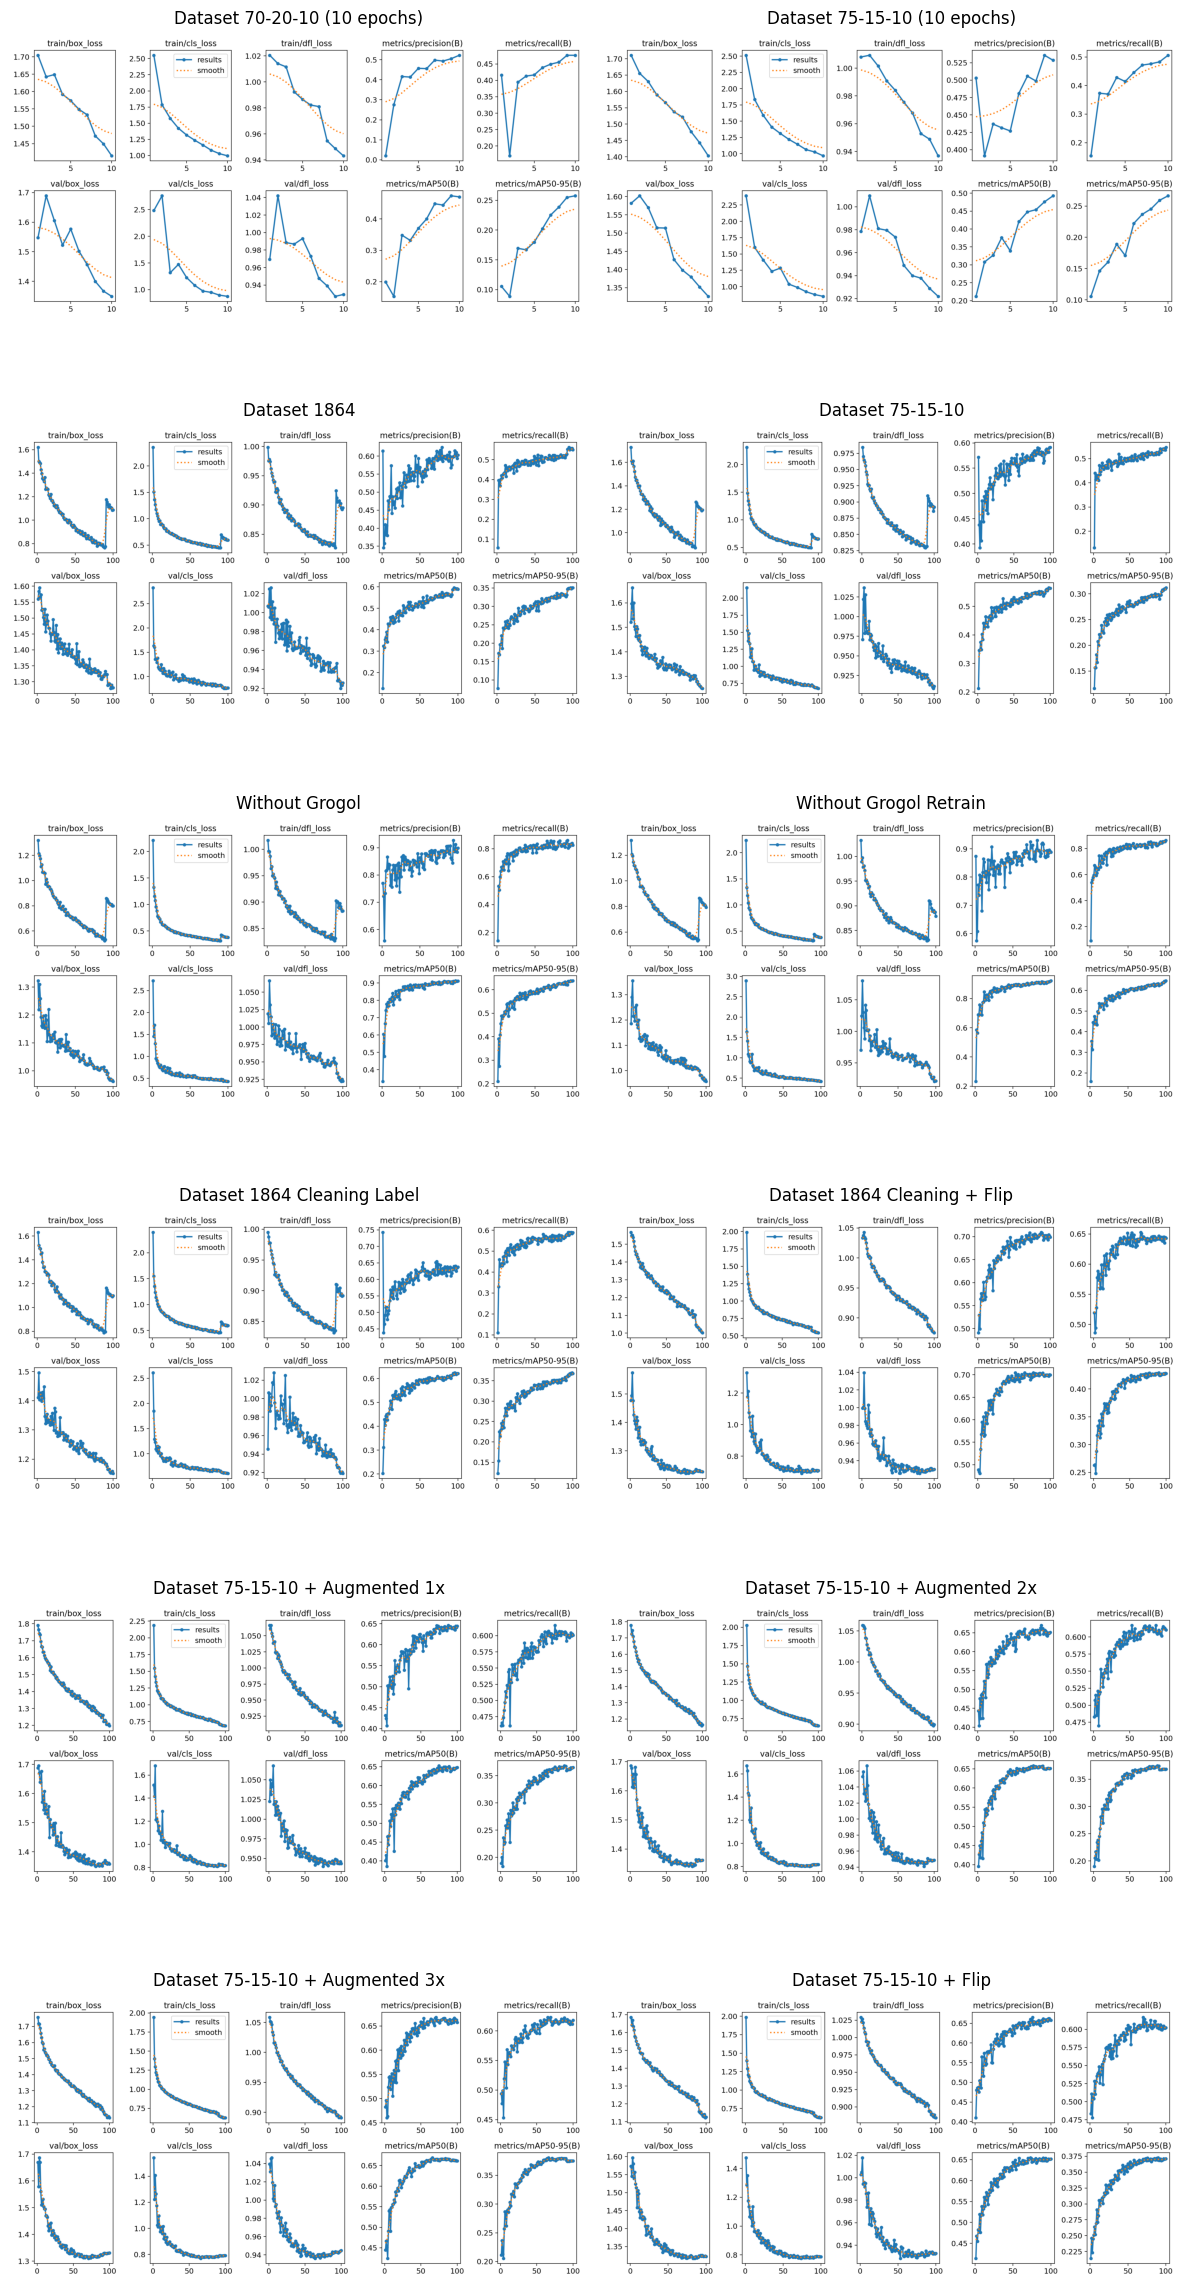

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/results.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/results.png",
    "runs/d_train/y11n_batch16_epochs100_val/results.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/results.png",
    "runs/withoutgrogol_train/y11n_batch16_epochs100/results.png",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/results.png",
    "runs/dataset_clean_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_clean_flip_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/results.png",
]

labels = [
    "Dataset 70-20-10 (10 epochs)",
    "Dataset 75-15-10 (10 epochs)",
    "Dataset 1864",
    "Dataset 75-15-10",
    "Without Grogol",
    "Without Grogol Retrain",
    "Dataset 1864 Cleaning Label",
    "Dataset 1864 Cleaning + Flip",
    "Dataset 75-15-10 + Augmented 1x",
    "Dataset 75-15-10 + Augmented 2x",
    "Dataset 75-15-10 + Augmented 3x",
    "Dataset 75-15-10 + Flip",
]

# Hitung jumlah baris
rows = (len(image_paths) + 1) // 2

# Ukuran figure menyesuaikan jumlah baris
plt.figure(figsize=(12, rows * 4))

# Loop setiap gambar dan tampilkan
for i, img_path in enumerate(image_paths):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(rows, 2, i + 1)
        plt.imshow(img)
        plt.title(labels[i] if i < len(labels) else f'PR Curve {i+1}')
        plt.axis('off')
    else:
        print(f"Gambar tidak ditemukan: {img_path}")

plt.tight_layout()
plt.show()